# Tier 7 · Notebook 33 — Markov Decision Processes & Dynamic Programming

> **Goal:** the foundations of **reinforcement learning** — the MDP formalism, **value functions**, the **Bellman equations**, and the two dynamic-programming algorithms (**value iteration** and **policy iteration**) that solve an MDP exactly — built from scratch on a gridworld. This is the bedrock under everything in Tier 7, and it's what makes the PPO in NB21's RLHF actually make sense.

**How RL differs from everything so far.** Supervised learning (all previous tiers) learns from *labeled examples*: here's an input, here's the right output. **Reinforcement learning** learns from *interaction and reward*: an **agent** takes **actions** in an **environment**, which returns a **reward** and a new **state**; there are no labels telling it the right action — only a scalar reward signal, often *delayed* (you win the game 40 moves after the good move). The agent must learn a **policy** (what to do in each state) that maximizes *long-term* reward. That credit-assignment-over-time problem is what makes RL distinct and hard.


## 0. The MDP — the formalism of sequential decisions

A **Markov Decision Process** is the mathematical model of an RL problem:
- **States** $s \in S$ — the situations the agent can be in.
- **Actions** $a \in A$ — the choices available.
- **Transitions** $P(s'\mid s,a)$ — the (possibly stochastic) dynamics: which next state follows.
- **Rewards** $R(s,a)$ — the immediate payoff.
- **Discount** $\gamma \in [0,1)$ — how much future rewards are worth vs immediate ones (a "patience" knob; also keeps infinite sums finite).

"**Markov**" means the future depends only on the *current* state, not the full history. The agent's goal is a **policy** $\pi(a\mid s)$ maximizing the expected **return** — the discounted sum of future rewards $G_t = \sum_{k\ge 0}\gamma^k r_{t+k}$. Let's build a concrete MDP: a gridworld.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

class GridWorld:
    """A grid: agent moves U/D/L/R; reach GOAL (+1), avoid TRAP (-1); small step cost; walls block."""
    def __init__(self):
        self.rows, self.cols = 4, 5
        self.goal, self.trap = (0,4), (1,4)
        self.walls = {(1,1),(2,1),(1,2)}
        self.actions = ["U","D","L","R"]
        self.moves = {"U":(-1,0),"D":(1,0),"L":(0,-1),"R":(0,1)}
        self.states = [(r,c) for r in range(self.rows) for c in range(self.cols)
                       if (r,c) not in self.walls]
        self.gamma = 0.9
    def is_terminal(self, s): return s in (self.goal, self.trap)
    def step_reward(self, s):
        if s == self.goal: return 1.0
        if s == self.trap: return -1.0
        return -0.04                                    # small cost per step -> prefer short paths
    def next_state(self, s, a):
        if self.is_terminal(s): return s
        dr, dc = self.moves[a]; ns = (s[0]+dr, s[1]+dc)
        if (ns[0]<0 or ns[0]>=self.rows or ns[1]<0 or ns[1]>=self.cols or ns in self.walls):
            return s                                     # bump into wall/edge -> stay
        return ns

env = GridWorld()
print(f"gridworld: {len(env.states)} states, actions {env.actions}, gamma {env.gamma}")
print(f"goal {env.goal} (+1), trap {env.trap} (-1), walls {env.walls}")


gridworld: 17 states, actions ['U', 'D', 'L', 'R'], gamma 0.9
goal (0, 4) (+1), trap (1, 4) (-1), walls {(1, 1), (1, 2), (2, 1)}


## 1. Value functions & the Bellman equation

The central objects of RL:
- **State value** $V^\pi(s)$ = expected return starting from $s$ and following policy $\pi$. "How good is it to be here?"
- **Action value** $Q^\pi(s,a)$ = expected return from taking action $a$ in $s$, then following $\pi$. "How good is this move?"

These satisfy the **Bellman equation** — a recursive consistency condition: the value of a state = immediate reward + discounted value of where you end up:
$$V^\pi(s) = \sum_a \pi(a\mid s)\Big[R(s,a) + \gamma\sum_{s'}P(s'\mid s,a)\,V^\pi(s')\Big].$$
The **optimal** value $V^*(s) = \max_a\big[R + \gamma\sum_{s'}P\,V^*(s')\big]$ replaces the policy-average with a max — "act optimally." Solving for $V^*$ gives the optimal policy: act greedily w.r.t. $V^*$. Dynamic programming does exactly this.


## 2. Value iteration — repeatedly apply the Bellman optimality update

**Value iteration** just turns the Bellman *optimality* equation into an update rule and iterates it to convergence:
$$V(s) \leftarrow \max_a\Big[R(s,a) + \gamma\sum_{s'}P(s'\mid s,a)\,V(s')\Big].$$
Each sweep propagates value one step further from the goal; repeat until $V$ stops changing. Then read off the optimal policy by taking the greedy (arg-max) action in each state.


In [2]:
def value_iteration(env, theta=1e-6):
    V = {s: 0.0 for s in env.states}
    history = []
    while True:
        delta = 0
        for s in env.states:
            if env.is_terminal(s):
                V[s] = env.step_reward(s); continue
            # Bellman optimality: best action's (reward + gamma * V(next))
            best = max(env.step_reward(env.next_state(s,a)) if env.is_terminal(env.next_state(s,a))
                       else env.step_reward(s) + env.gamma*V[env.next_state(s,a)]
                       for a in env.actions)
            delta = max(delta, abs(best - V[s])); V[s] = best
        history.append(sum(V.values()))
        if delta < theta: break
    # extract greedy policy
    policy = {}
    for s in env.states:
        if env.is_terminal(s): continue
        policy[s] = max(env.actions, key=lambda a:
            (env.step_reward(env.next_state(s,a)) if env.is_terminal(env.next_state(s,a))
             else env.step_reward(s)+env.gamma*V[env.next_state(s,a)]))
    return V, policy, history

V_star, pi_star, hist = value_iteration(env)
print(f"value iteration converged in {len(hist)} sweeps")
print(f"V(start=(3,0)) = {V_star[(3,0)]:.3f}")


value iteration converged in 5 sweeps
V(start=(3,0)) = 0.344


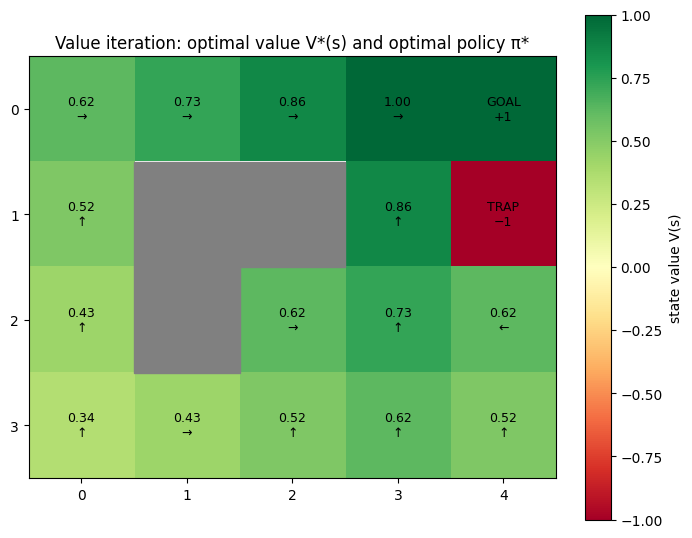

In [3]:
def plot_gridworld(env, V, policy, title):
    grid = np.full((env.rows, env.cols), np.nan)
    for s in env.states: grid[s] = V[s]
    fig, ax = plt.subplots(figsize=(7,5.5))
    im = ax.imshow(grid, cmap="RdYlGn", vmin=-1, vmax=1)
    arrow = {"U":"↑","D":"↓","L":"←","R":"→"}
    for s in env.states:
        r,c = s
        if s == env.goal: txt="GOAL\n+1"
        elif s == env.trap: txt="TRAP\n−1"
        else: txt=f"{V[s]:.2f}\n{arrow[policy[s]]}"
        ax.text(c, r, txt, ha="center", va="center", fontsize=9)
    for (r,c) in env.walls: ax.add_patch(plt.Rectangle((c-.5,r-.5),1,1,color="gray"))
    ax.set_xticks(range(env.cols)); ax.set_yticks(range(env.rows)); ax.set_title(title)
    plt.colorbar(im, label="state value V(s)", fraction=0.046); plt.tight_layout(); plt.show()

plot_gridworld(env, V_star, pi_star, "Value iteration: optimal value V*(s) and optimal policy π*")


**What to notice.** The colors are the optimal **value** of each cell (green = high, red = low), and the arrows are the optimal **policy** — the best action to take there. Notice the values form a gradient *flowing outward from the goal*: cells near the +1 goal are worth ~1, and value decays with distance (by $\gamma$ per step) and with the step cost. The policy arrows all point along the highest-value path toward the goal and *away* from the trap — the agent has "solved" the maze. Value iteration computed this by propagating the goal's reward backward through the Bellman equation, one sweep at a time.


## 3. Policy iteration — evaluate, then improve, repeat

An alternative that often converges in fewer iterations. It alternates two steps:
1. **Policy evaluation:** given a fixed policy $\pi$, solve the (linear) Bellman equations for $V^\pi$ — "how good is this policy?"
2. **Policy improvement:** update $\pi$ to act greedily w.r.t. $V^\pi$ — "do better where you can."

Repeat until the policy stops changing (the **policy improvement theorem** guarantees each step is no worse, so it converges to $\pi^*$). It should reach the *same* optimal policy as value iteration.


In [4]:
def policy_iteration(env):
    policy = {s: np.random.choice(env.actions) for s in env.states if not env.is_terminal(s)}
    iters = 0
    while True:
        iters += 1
        # --- policy evaluation (iterative) ---
        V = {s: 0.0 for s in env.states}
        for _ in range(200):
            for s in env.states:
                if env.is_terminal(s): V[s]=env.step_reward(s); continue
                ns = env.next_state(s, policy[s])
                V[s] = (env.step_reward(ns) if env.is_terminal(ns)
                        else env.step_reward(s) + env.gamma*V[ns])
        # --- policy improvement ---
        stable = True
        for s in env.states:
            if env.is_terminal(s): continue
            best = max(env.actions, key=lambda a:
                (env.step_reward(env.next_state(s,a)) if env.is_terminal(env.next_state(s,a))
                 else env.step_reward(s)+env.gamma*V[env.next_state(s,a)]))
            if best != policy[s]: stable=False
            policy[s]=best
        if stable: return V, policy, iters

V_pi, pi_pi, iters = policy_iteration(env)
agree = all(pi_pi[s]==pi_star[s] for s in pi_pi)
print(f"policy iteration converged in {iters} policy updates")
print(f"same optimal policy as value iteration: {agree}  ✅")


policy iteration converged in 6 policy updates
same optimal policy as value iteration: True  ✅


**What to notice.** Policy iteration reaches the **identical optimal policy** as value iteration, usually in far fewer outer iterations (each is more expensive — it fully evaluates a policy). Both are **dynamic programming**: they require knowing the environment's model ($P$ and $R$) and sweep over *all* states. That's their limitation — real problems have unknown dynamics and astronomically many states. The next notebooks (NB34–37) drop the "known model" assumption and learn from *sampled experience* instead, scaling RL to problems where you can only *try things and see what happens*.

## 4. What you built / learned
- The **MDP** formalism: states, actions, transitions, rewards, discount, policy, return.
- **Value functions** $V^\pi, Q^\pi$ and the **Bellman equation** (value = reward + discounted future value).
- **Value iteration**: iterate the Bellman optimality update to $V^*$, then act greedily.
- **Policy iteration**: alternate policy evaluation and improvement; same optimum, fewer iterations.
- The DP limitation: needs a known model and full state sweeps → motivates model-free RL (NB34).

## 5. Exercises
1. **Discount sweep.** Vary $\gamma$ (0.5, 0.9, 0.99); how does the optimal policy / value change? What does $\gamma\to 0$ vs $\gamma\to 1$ mean?
2. **Stochastic transitions.** Make actions succeed 80% of the time (20% slip sideways); re-solve. Does the policy become more cautious near the trap?
3. **Q-values.** Compute $Q^*(s,a)$ for all state-actions; verify $V^*(s)=\max_a Q^*(s,a)$.
4. **Step cost.** Vary the per-step penalty; when does the agent prefer a risky shortcut past the trap?
5. **Convergence rate.** Plot $\|V_{k+1}-V_k\|$ per sweep; relate the rate to $\gamma$ (it contracts by $\gamma$).
6. **Bigger maze.** Scale to a 20×20 maze; where does exhaustive DP start to hurt?

## 6. Interview / residency framing
- *"What is an MDP?"* → states, actions, transitions $P(s'|s,a)$, rewards, discount $\gamma$; Markov = future depends only on current state; goal = policy maximizing expected discounted return.
- *"What's the Bellman equation?"* → value = immediate reward + discounted expected value of the next state; the recursive consistency condition RL is built on.
- *"Value vs policy iteration?"* → both DP; value iteration iterates the Bellman-optimality max; policy iteration alternates evaluation + greedy improvement (fewer, costlier iterations); same optimum.
- *"Why can't we always use DP?"* → it needs a known model ($P,R$) and sweeps all states — infeasible for unknown dynamics or huge/continuous state spaces → model-free RL.
- *"What is the discount factor for?"* → weighs future vs immediate reward and keeps infinite-horizon returns finite.

## 📚 References & papers

This notebook builds on:

- **Reinforcement Learning: An Introduction** — Sutton & Barto (2018, 2nd ed., free online). The canonical RL text; Chapters 3–4 cover MDPs and dynamic programming.
- **Dynamic Programming** — Bellman (1957). The origin of value functions and the Bellman equation.
- **A Markovian Decision Process** — Bellman (1957), *Journal of Mathematics and Mechanics*.

---
**Next:** *Tier 7 · Notebook 34 — Model-free RL*: learning from sampled experience without knowing the environment's model — Monte Carlo, temporal-difference learning, SARSA, and Q-learning.
